In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/adityaaryan526/hasoc-dataset/HASOC /.gitignore
/kaggle/input/datasets/adityaaryan526/hasoc-dataset/HASOC /english/english_2019_1.tsv
/kaggle/input/datasets/adityaaryan526/hasoc-dataset/HASOC /english/english_2020.xlsx
/kaggle/input/datasets/adityaaryan526/hasoc-dataset/HASOC /english/en_Hasoc2021_test_task1.csv
/kaggle/input/datasets/adityaaryan526/hasoc-dataset/HASOC /english/english_2021.csv
/kaggle/input/datasets/adityaaryan526/hasoc-dataset/HASOC /english/english_2019_2.tsv
/kaggle/input/datasets/adityaaryan526/hasoc-dataset/HASOC /hindi/hindi_2019_1.tsv
/kaggle/input/datasets/adityaaryan526/hasoc-dataset/HASOC /hindi/hindi_2021.csv
/kaggle/input/datasets/adityaaryan526/hasoc-dataset/HASOC /hindi/hindi_2020.xlsx
/kaggle/input/datasets/adityaaryan526/hasoc-dataset/HASOC /hindi/hindi_2019_2.tsv
/kaggle/input/datasets/adityaaryan526/hasoc-dataset/HASOC /hindi/hi_Hasoc2021_test_task1.csv
/kaggle/input/datasets/adityaaryan526/jigsaw/Jigsaw/sample_submission.csv
/k

In [2]:
!pip install transformers datasets openpyxl -q
!pip install -q scikit-learn seaborn peft bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 32.6 MB/s eta 0:00:00:00:0100:01


In [3]:
import os
import re
import json
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    confusion_matrix, classification_report,
    roc_curve, auc, precision_recall_curve, accuracy_score
)
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    Trainer, TrainingArguments, DataCollatorWithPadding
)
from peft import LoraConfig, get_peft_model, TaskType
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
EXPERIMENT_NAME = "Qwen2.5_Merged"
MODEL_NAME = "Qwen/Qwen2.5-0.5B"
# ============================================================

SAVE_DIR = f'/kaggle/working/{EXPERIMENT_NAME}_plots'
os.makedirs(SAVE_DIR, exist_ok=True)

LABEL_COLS = ['toxic', 'obscene', 'insult', 'identity_hate', 'threat', 'severe_toxic']

In [4]:
def clean_text(text):
    text = str(text)
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#\w+", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

In [5]:
jigsaw = pd.read_csv('/kaggle/input/datasets/adityaaryan526/jigsaw/Jigsaw/train.csv')

jigsaw = jigsaw[[
    'comment_text',
    'toxic', 'obscene', 'insult', 'identity_hate', 'threat', 'severe_toxic'
]]
jigsaw.columns = [
    'text', 'toxic', 'obscene', 'insult', 'identity_hate', 'threat', 'severe_toxic'
]
jigsaw['text'] = jigsaw['text'].apply(clean_text)
jigsaw['source'] = 'jigsaw'

print("Jigsaw:", jigsaw.shape)

Jigsaw: (159571, 8)


In [6]:
hasoc_data = []
base_path = "/kaggle/input/datasets/adityaaryan526/hasoc-dataset/HASOC "

def map_hasoc(label):
    if label == 0:
        return [0, 0, 0, 0, 0, 0]
    else:
        return [1, 0, 1, 0, 0, 0]

for root, dirs, files in os.walk(base_path):
    for file in files:
        file_path = os.path.join(root, file)
        try:
            if file.endswith(".tsv"):
                df_h = pd.read_csv(file_path, sep='\t')
            elif file.endswith(".csv"):
                df_h = pd.read_csv(file_path)
            elif file.endswith(".xlsx"):
                df_h = pd.read_excel(file_path)
            else:
                continue

            text_col = None
            label_col = None
            for col in df_h.columns:
                if 'text' in col.lower():
                    text_col = col
                if 'task_1' in col.lower() or 'label' in col.lower():
                    label_col = col

            if text_col and label_col:
                temp = df_h[[text_col, label_col]].copy()
                temp.columns = ['text', 'label']
                temp['text'] = temp['text'].apply(clean_text)
                temp[LABEL_COLS] = pd.DataFrame(
                    temp['label'].apply(map_hasoc).tolist(), index=temp.index
                )
                temp = temp.drop(columns=['label'])
                temp['source'] = 'hasoc'
                hasoc_data.append(temp)
        except Exception:
            continue

hasoc = pd.concat(hasoc_data, ignore_index=True)
print("HASOC:", hasoc.shape)

HASOC: (21425, 8)


In [7]:
with open('/kaggle/input/datasets/adityaaryan526/mmhs-dataset/MMHS/MMHS150K_GT.json') as f:
    data = json.load(f)

texts, labels = [], []

def map_mmhs(label_list):
    if all(l == 0 for l in label_list):
        return [0, 0, 0, 0, 0, 0]
    else:
        return [1, 0, 1, 1, 0, 0]

for key in data:
    item = data[key]
    text = item.get("tweet_text", "")
    label_list = item.get("labels", [])
    texts.append(clean_text(text))
    labels.append(map_mmhs(label_list))

mmhs = pd.DataFrame(texts, columns=["text"])
mmhs[LABEL_COLS] = pd.DataFrame(labels)
mmhs['source'] = 'mmhs'
print("MMHS:", mmhs.shape)

MMHS: (149823, 8)


In [8]:
df = pd.concat([jigsaw, hasoc, mmhs], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print("Final Merged Dataset:", df.shape)
print("\nPer-label positive counts:")
print(df[LABEL_COLS].sum())
print("\nSource distribution:")
print(df['source'].value_counts())

Final Merged Dataset: (330819, 8)

Per-label positive counts:
toxic            128611
obscene            8449
insult           121194
identity_hate     93297
threat              478
severe_toxic       1595
dtype: int64

Source distribution:
source
jigsaw    159571
mmhs      149823
hasoc      21425
Name: count, dtype: int64


In [9]:
texts = df['text'].tolist()
labels = df[LABEL_COLS].values

train_texts, val_texts, train_labels, val_labels = train_test_split(
    texts, labels, test_size=0.1, random_state=42
)

print(f"Train: {len(train_texts)}, Val: {len(val_texts)}")

Train: 297737, Val: 33082


In [10]:
class ToxicDataset(Dataset):
    def __init__(self, texts, labels, tokenizer):
        self.encodings = tokenizer(texts, truncation=True, padding=False, max_length=64)
        self.labels = labels

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.float)
        return item

    def __len__(self):
        return len(self.labels)

In [11]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = (torch.sigmoid(torch.tensor(logits)) > 0.5).int().numpy()

    results = {
        "f1_micro": f1_score(labels, preds, average="micro", zero_division=0),
        "f1_macro": f1_score(labels, preds, average="macro", zero_division=0),
        "f1_weighted": f1_score(labels, preds, average="weighted", zero_division=0),
        "precision_micro": precision_score(labels, preds, average="micro", zero_division=0),
        "recall_micro": recall_score(labels, preds, average="micro", zero_division=0),
    }

    for i, name in enumerate(LABEL_COLS):
        results[f"f1_{name}"] = f1_score(labels[:, i], preds[:, i], zero_division=0)

    return results

In [12]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

train_dataset = ToxicDataset(train_texts, train_labels, tokenizer)
val_dataset = ToxicDataset(val_texts, val_labels, tokenizer)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=6,
    problem_type="multi_label_classification",
    trust_remote_code=True,
)
model.config.pad_token_id = tokenizer.pad_token_id

lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=8,                        # reduced from 16 — faster, still effective
    lora_alpha=16,              # scaled proportionally
    lora_dropout=0.1,
    target_modules=["q_proj", "v_proj"],
)
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

config.json:   0%|          | 0.00/681 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Qwen2ForSequenceClassification LOAD REPORT from: Qwen/Qwen2.5-0.5B
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 546,048 || all params: 494,584,192 || trainable%: 0.1104


In [13]:
training_args = TrainingArguments(
    output_dir=f"/kaggle/working/{EXPERIMENT_NAME}_output",
    eval_strategy="epoch",
    save_strategy="no",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    gradient_accumulation_steps=1,     # no accumulation, effective batch = 32 (16 × 2 GPUs)
    num_train_epochs=3,
    learning_rate=2e-4,                # slightly higher LR for LoRA convergence
    logging_steps=200,
    dataloader_num_workers=4,
    report_to="none",
    warmup_ratio=0.1,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    data_collator=data_collator,
)

trainer.train()

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,F1 Micro,F1 Macro,F1 Weighted,Precision Micro,Recall Micro,F1 Toxic,F1 Obscene,F1 Insult,F1 Identity Hate,F1 Threat,F1 Severe Toxic
1,0.356424,0.350265,0.736057,0.485537,0.731511,0.719236,0.753684,0.771611,0.673851,0.750298,0.674681,0.000000,0.042781
2,0.334324,0.340519,0.718842,0.536927,0.716731,0.765443,0.677588,0.746880,0.717984,0.737609,0.660435,0.105263,0.253394
3,0.320813,0.338451,0.736195,0.606396,0.735321,0.735274,0.737118,0.759304,0.754364,0.750356,0.690654,0.324324,0.359375


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


TrainOutput(global_step=27915, training_loss=0.37681419390323617, metrics={'train_runtime': 28018.2313, 'train_samples_per_second': 31.88, 'train_steps_per_second': 0.996, 'total_flos': 1.2293985546248986e+17, 'train_loss': 0.37681419390323617, 'epoch': 3.0})

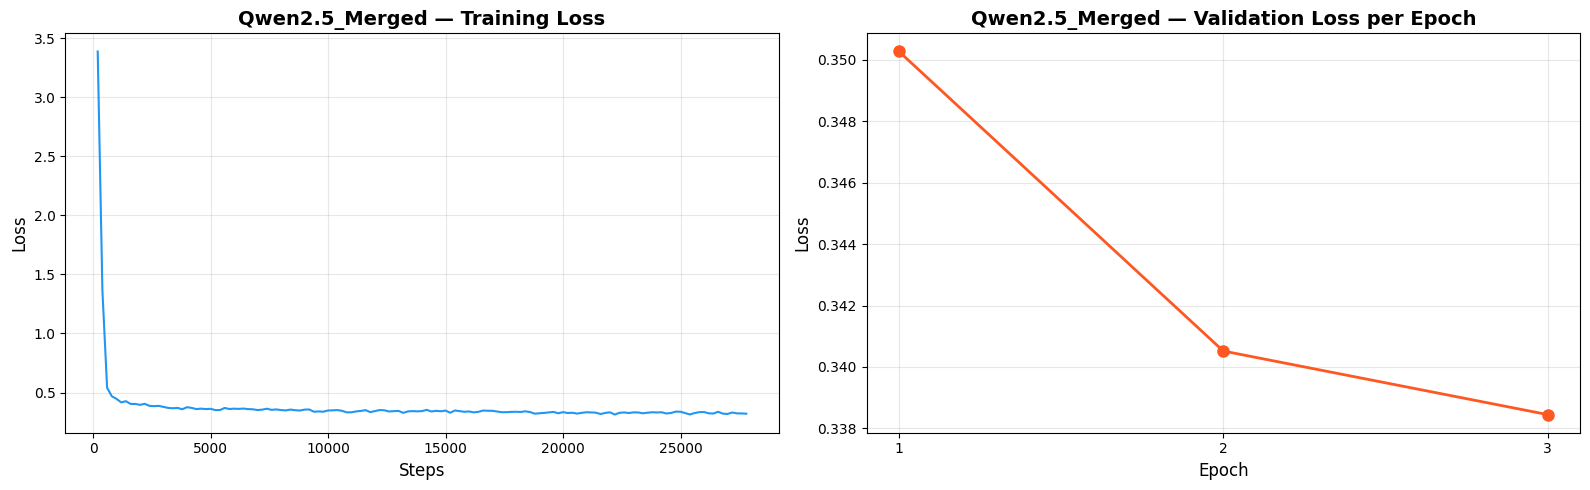

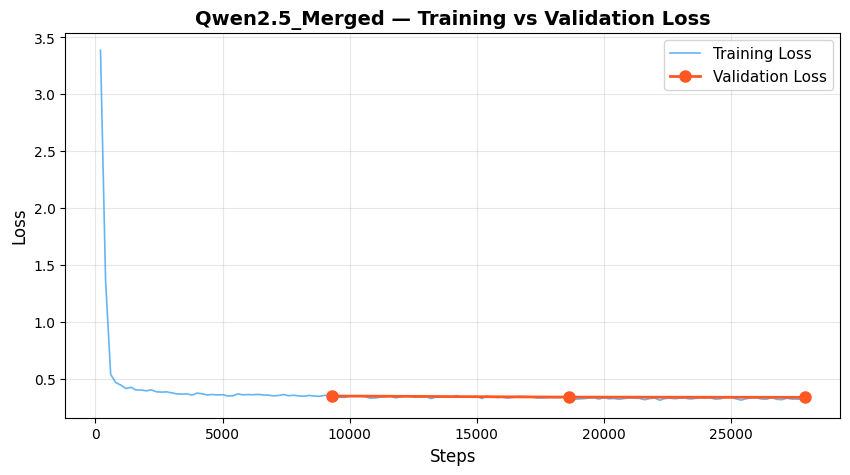

In [14]:
train_losses, eval_losses = [], []
train_steps, eval_steps = [], []

for entry in trainer.state.log_history:
    if 'loss' in entry and 'eval_loss' not in entry:
        train_losses.append(entry['loss'])
        train_steps.append(entry['step'])
    if 'eval_loss' in entry:
        eval_losses.append(entry['eval_loss'])
        eval_steps.append(entry['step'])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(train_steps, train_losses, color='#2196F3', linewidth=1.5)
axes[0].set_xlabel('Steps', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title(f'{EXPERIMENT_NAME} — Training Loss', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

epoch_nums = list(range(1, len(eval_losses) + 1))
axes[1].plot(epoch_nums, eval_losses, color='#FF5722', linewidth=2, marker='o', markersize=8)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].set_title(f'{EXPERIMENT_NAME} — Validation Loss per Epoch', fontsize=14, fontweight='bold')
axes[1].set_xticks(epoch_nums)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/loss_curves.png', dpi=300, bbox_inches='tight')
plt.show()

# Combined overlay
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(train_steps, train_losses, color='#2196F3', linewidth=1.2, alpha=0.7, label='Training Loss')
ax.plot(eval_steps, eval_losses, color='#FF5722', linewidth=2, marker='o', markersize=8, label='Validation Loss')
ax.set_xlabel('Steps', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title(f'{EXPERIMENT_NAME} — Training vs Validation Loss', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.savefig(f'{SAVE_DIR}/loss_combined.png', dpi=300, bbox_inches='tight')
plt.show()

In [15]:
preds_output = trainer.predict(val_dataset)
logits = preds_output.predictions
probs = torch.sigmoid(torch.tensor(logits)).numpy()
preds = (probs > 0.5).astype(int)
true_labels = np.array(val_labels)

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


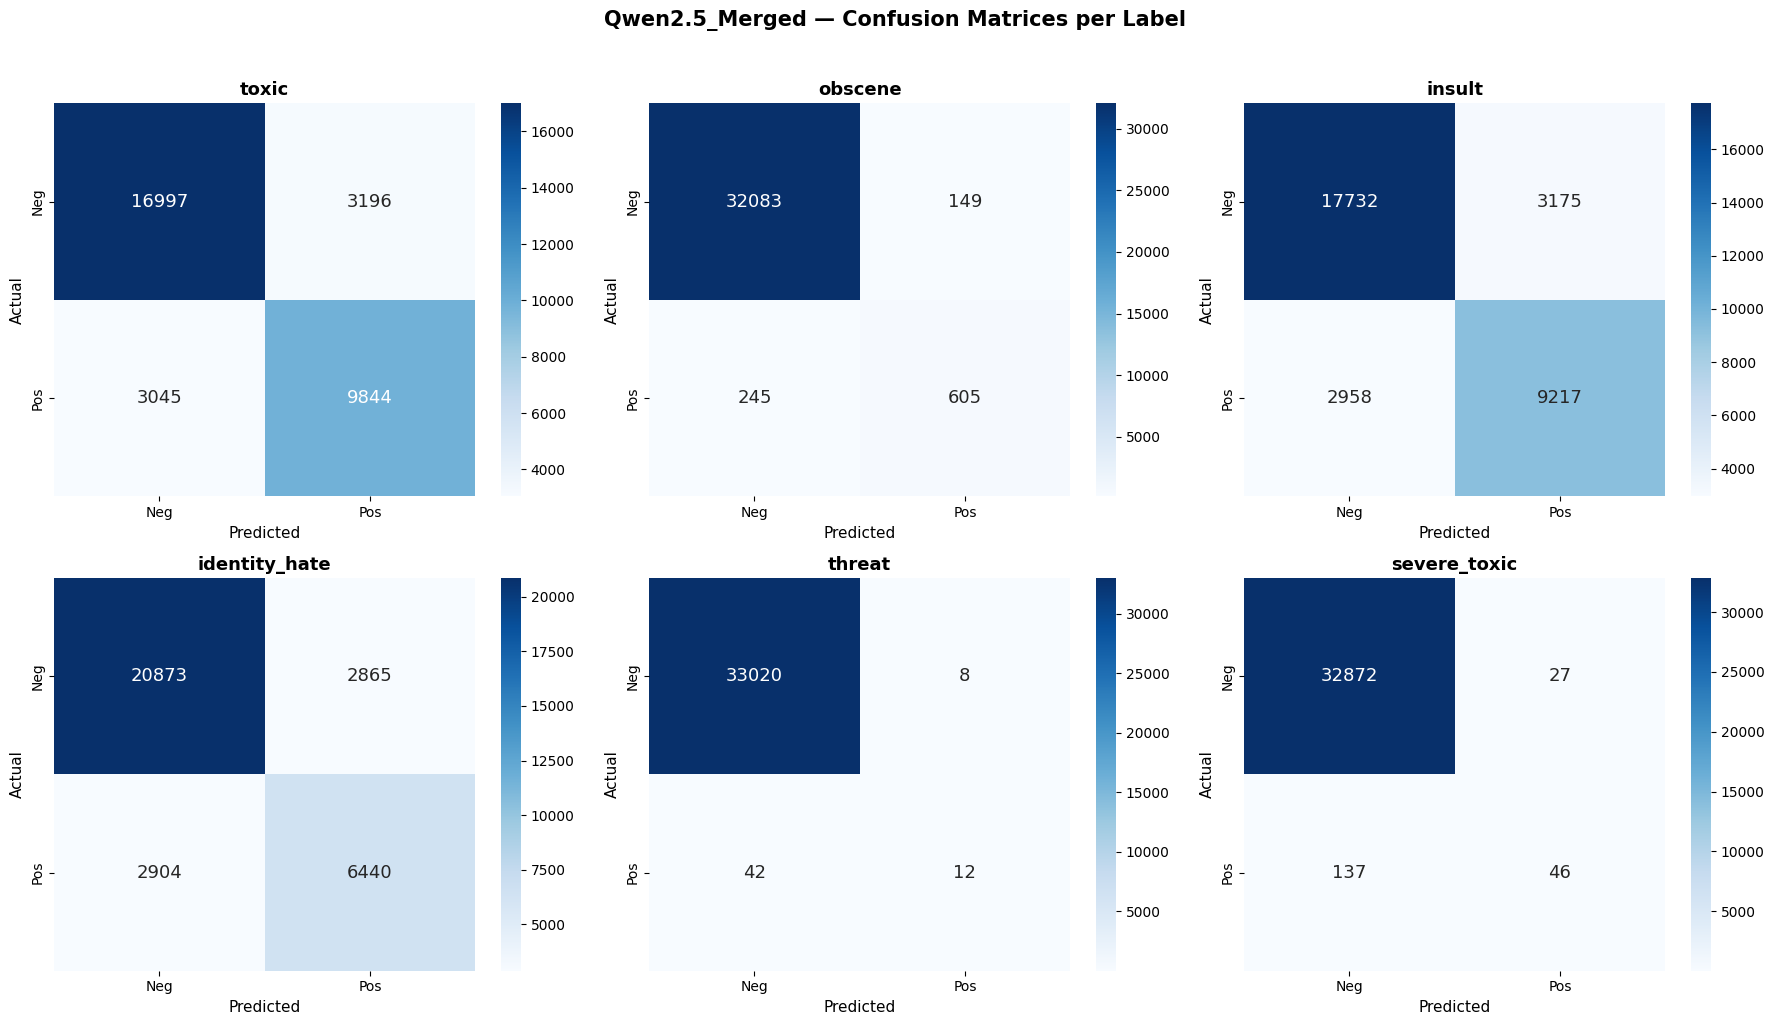

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, label in enumerate(LABEL_COLS):
    cm = confusion_matrix(true_labels[:, i], preds[:, i])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Neg', 'Pos'], yticklabels=['Neg', 'Pos'],
                annot_kws={'size': 13})
    axes[i].set_xlabel('Predicted', fontsize=11)
    axes[i].set_ylabel('Actual', fontsize=11)
    axes[i].set_title(f'{label}', fontsize=13, fontweight='bold')

fig.suptitle(f'{EXPERIMENT_NAME} — Confusion Matrices per Label',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

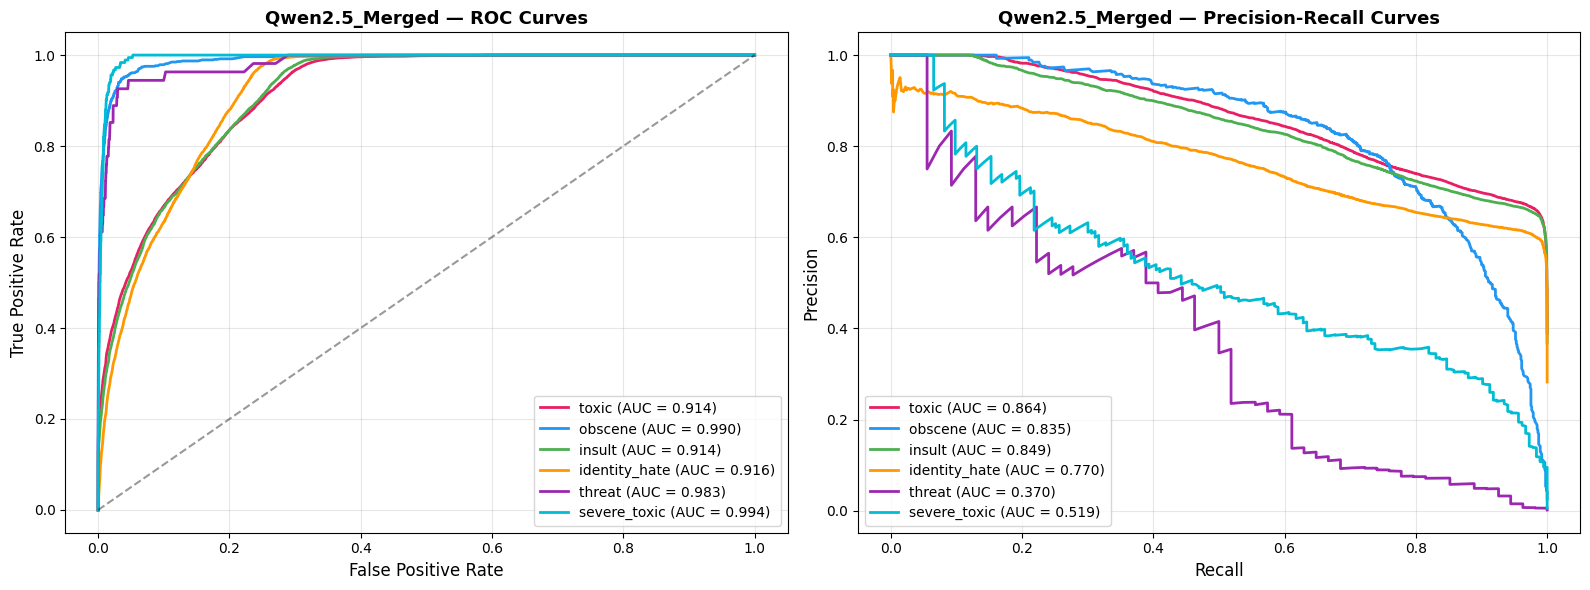

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors_list = ['#E91E63', '#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#00BCD4']

# ROC curves
for i, label in enumerate(LABEL_COLS):
    fpr, tpr, _ = roc_curve(true_labels[:, i], probs[:, i])
    roc_auc_val = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, linewidth=2, color=colors_list[i],
                 label=f'{label} (AUC = {roc_auc_val:.3f})')

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.4)
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate', fontsize=12)
axes[0].set_title(f'{EXPERIMENT_NAME} — ROC Curves', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10, loc='lower right')
axes[0].grid(True, alpha=0.3)

# PR curves
for i, label in enumerate(LABEL_COLS):
    precision_vals, recall_vals, _ = precision_recall_curve(true_labels[:, i], probs[:, i])
    pr_auc_val = auc(recall_vals, precision_vals)
    axes[1].plot(recall_vals, precision_vals, linewidth=2, color=colors_list[i],
                 label=f'{label} (AUC = {pr_auc_val:.3f})')

axes[1].set_xlabel('Recall', fontsize=12)
axes[1].set_ylabel('Precision', fontsize=12)
axes[1].set_title(f'{EXPERIMENT_NAME} — Precision-Recall Curves', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10, loc='lower left')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/roc_pr_curves.png', dpi=300, bbox_inches='tight')
plt.show()

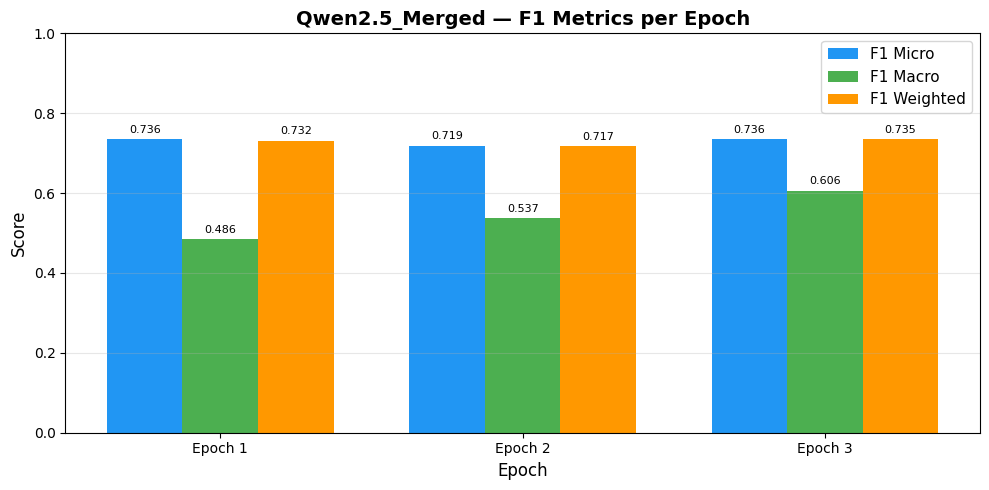

In [18]:
epoch_metrics = {'epoch': [], 'f1_micro': [], 'f1_macro': [], 'f1_weighted': []}

for entry in trainer.state.log_history:
    if 'eval_f1_micro' in entry:
        epoch_metrics['epoch'].append(int(entry.get('epoch', 0)))
        epoch_metrics['f1_micro'].append(entry['eval_f1_micro'])
        epoch_metrics['f1_macro'].append(entry['eval_f1_macro'])
        epoch_metrics['f1_weighted'].append(entry['eval_f1_weighted'])

x = np.arange(len(epoch_metrics['epoch']))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width, epoch_metrics['f1_micro'], width, label='F1 Micro', color='#2196F3')
bars2 = ax.bar(x, epoch_metrics['f1_macro'], width, label='F1 Macro', color='#4CAF50')
bars3 = ax.bar(x + width, epoch_metrics['f1_weighted'], width, label='F1 Weighted', color='#FF9800')

ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title(f'{EXPERIMENT_NAME} — F1 Metrics per Epoch', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f'Epoch {e}' for e in epoch_metrics['epoch']])
ax.legend(fontsize=11)
ax.set_ylim(0, 1.0)
ax.grid(True, alpha=0.3, axis='y')

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/metrics_per_epoch.png', dpi=300, bbox_inches='tight')
plt.show()

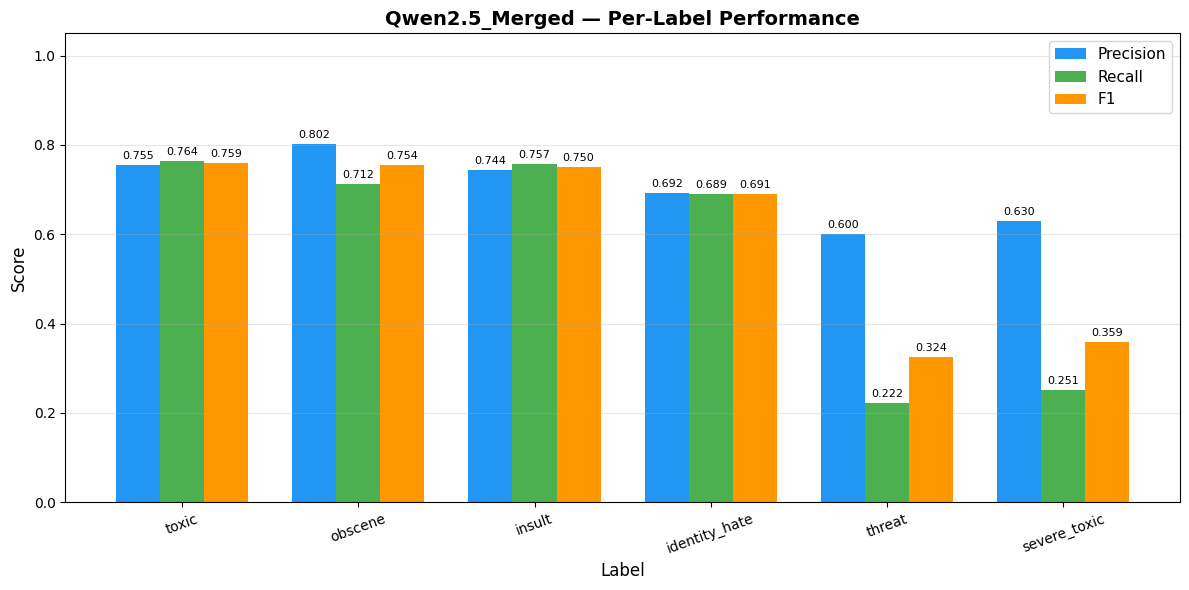

In [19]:
per_label_f1 = [f1_score(true_labels[:, i], preds[:, i], zero_division=0) for i in range(len(LABEL_COLS))]
per_label_prec = [precision_score(true_labels[:, i], preds[:, i], zero_division=0) for i in range(len(LABEL_COLS))]
per_label_rec = [recall_score(true_labels[:, i], preds[:, i], zero_division=0) for i in range(len(LABEL_COLS))]

x = np.arange(len(LABEL_COLS))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width, per_label_prec, width, label='Precision', color='#2196F3')
bars2 = ax.bar(x, per_label_rec, width, label='Recall', color='#4CAF50')
bars3 = ax.bar(x + width, per_label_f1, width, label='F1', color='#FF9800')

ax.set_xlabel('Label', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title(f'{EXPERIMENT_NAME} — Per-Label Performance', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(LABEL_COLS, rotation=20, fontsize=10)
ax.legend(fontsize=11)
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3, axis='y')

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/per_label_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

In [20]:
print("=" * 70)
print(f"FINAL VALIDATION RESULTS — {EXPERIMENT_NAME}")
print("=" * 70)

print("\nPer-label classification report:\n")
print(classification_report(true_labels, preds, target_names=LABEL_COLS, zero_division=0))

final_metrics = {
    'experiment': EXPERIMENT_NAME,
    'f1_micro': f1_score(true_labels, preds, average='micro', zero_division=0),
    'f1_macro': f1_score(true_labels, preds, average='macro', zero_division=0),
    'f1_weighted': f1_score(true_labels, preds, average='weighted', zero_division=0),
    'precision_micro': precision_score(true_labels, preds, average='micro', zero_division=0),
    'recall_micro': recall_score(true_labels, preds, average='micro', zero_division=0),
}

# Per-label metrics
for i, name in enumerate(LABEL_COLS):
    final_metrics[f'f1_{name}'] = f1_score(true_labels[:, i], preds[:, i], zero_division=0)
    fpr_i, tpr_i, _ = roc_curve(true_labels[:, i], probs[:, i])
    final_metrics[f'roc_auc_{name}'] = auc(fpr_i, tpr_i)

metrics_df = pd.DataFrame([final_metrics])
metrics_df.to_csv(f'{SAVE_DIR}/final_metrics.csv', index=False)
print(f"\nAll plots and metrics saved to {SAVE_DIR}/")
print(metrics_df.to_string(index=False))

FINAL VALIDATION RESULTS — Qwen2.5_Merged

Per-label classification report:

               precision    recall  f1-score   support

        toxic       0.75      0.76      0.76     12889
      obscene       0.80      0.71      0.75       850
       insult       0.74      0.76      0.75     12175
identity_hate       0.69      0.69      0.69      9344
       threat       0.60      0.22      0.32        54
 severe_toxic       0.63      0.25      0.36       183

    micro avg       0.74      0.74      0.74     35495
    macro avg       0.70      0.57      0.61     35495
 weighted avg       0.73      0.74      0.74     35495
  samples avg       0.31      0.29      0.30     35495


All plots and metrics saved to /kaggle/working/Qwen2.5_Merged_plots/
    experiment  f1_micro  f1_macro  f1_weighted  precision_micro  recall_micro  f1_toxic  roc_auc_toxic  f1_obscene  roc_auc_obscene  f1_insult  roc_auc_insult  f1_identity_hate  roc_auc_identity_hate  f1_threat  roc_auc_threat  f1_severe_toxic 